# Training

Mounted at /content/drive

Training region: Surface
Samples: 55677
Spatial blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Temporal blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Fitting 38 folds for each of 50 candidates, totalling 1900 fits
Test RMSE:       0.3255
Test MAE:        0.2046
Test R²  : 0.8383


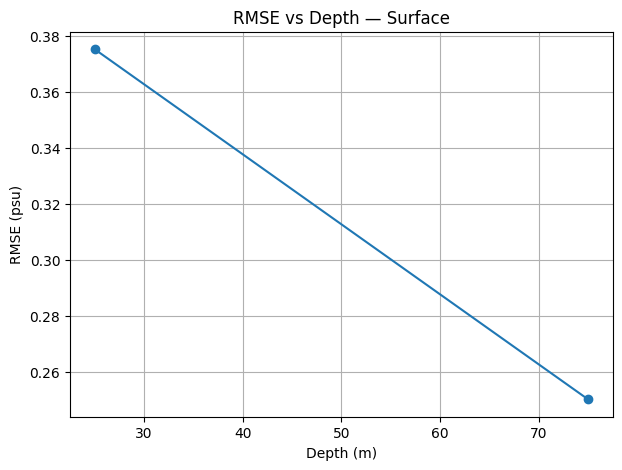

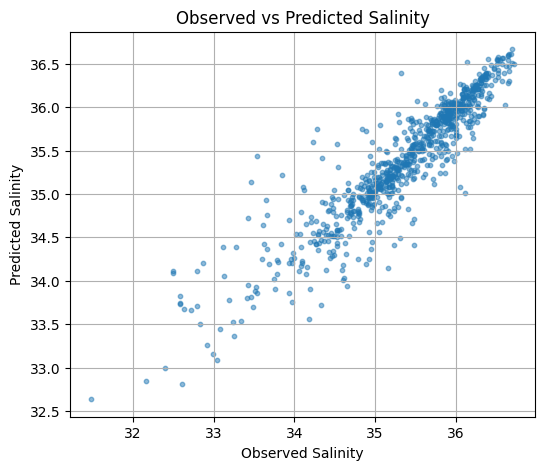

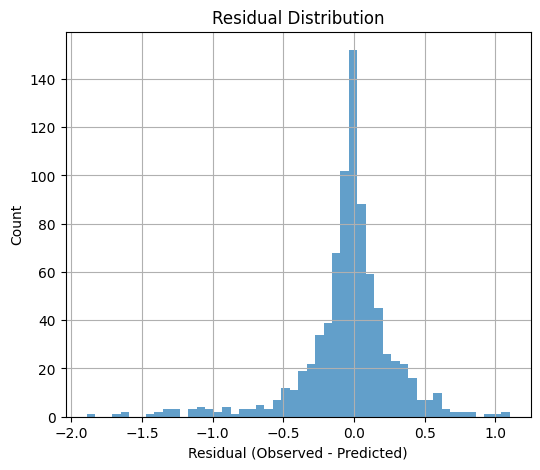

Saved XGBoost bundle at: /content/drive/MyDrive/INCOIS/Models/xgb_Surface_bundle.pkl
Best Hyperparameters: {'model__subsample': 0.7, 'model__reg_lambda': 1, 'model__reg_alpha': 0.1, 'model__n_estimators': 1200, 'model__min_child_weight': 10, 'model__max_depth': 8, 'model__learning_rate': 0.01, 'model__gamma': 0.1, 'model__colsample_bytree': 0.85}

Training region: Middle
Samples: 157922
Spatial blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Temporal blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Fitting 39 folds for each of 30 candidates, totalling 1170 fits
Test RMSE:       0.0473
Test MAE:        0.0287
Test R²  : 0.8804


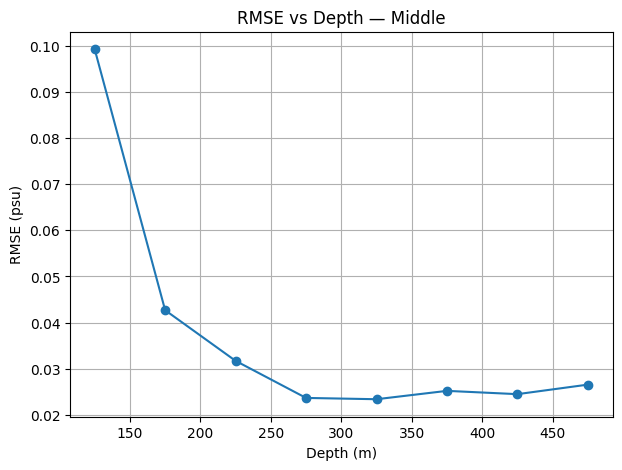

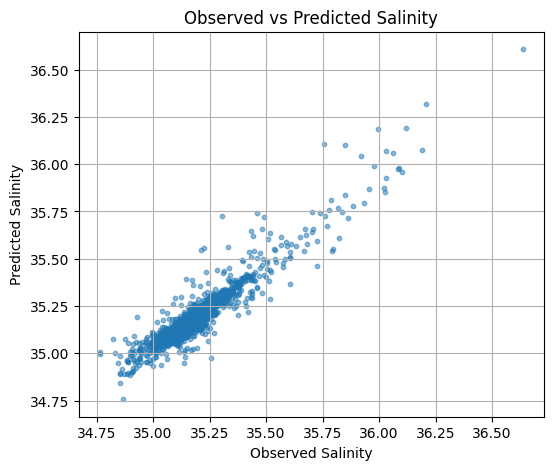

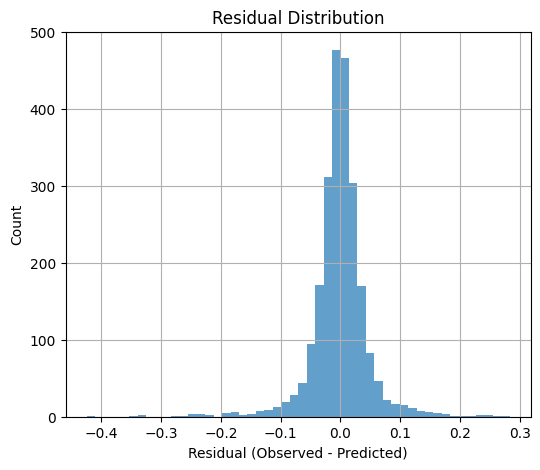

Saved XGBoost bundle at: /content/drive/MyDrive/INCOIS/Models/xgb_Middle_bundle.pkl
Best Hyperparameters: {'model__subsample': 0.85, 'model__reg_lambda': 1, 'model__reg_alpha': 0, 'model__n_estimators': 900, 'model__min_child_weight': 20, 'model__max_depth': 7, 'model__learning_rate': 0.03, 'model__gamma': 0, 'model__colsample_bytree': 0.85}

Training region: Deep
Samples: 230818
Spatial blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
Temporal blocks: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)]
Fitting 37 folds for each of 30 candidates, totalling 1110 fits
Test RMSE:       0.0176
Test MAE:        0.0104
Test R²  : 0.9836


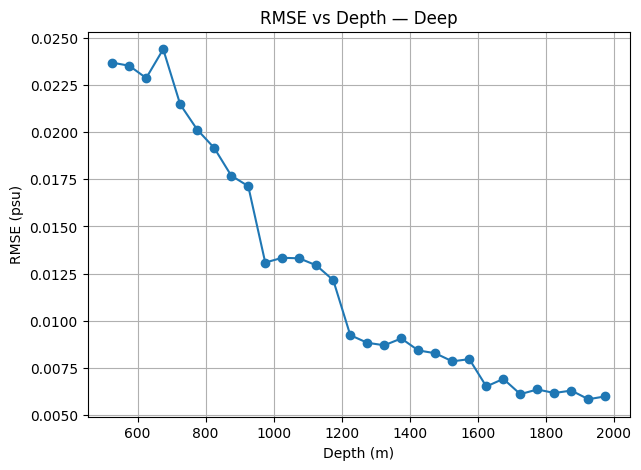

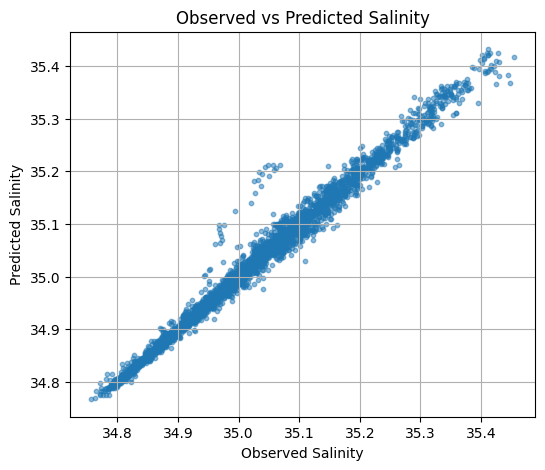

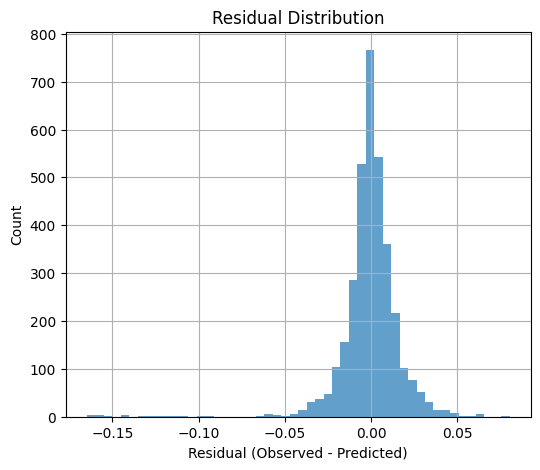

Saved XGBoost bundle at: /content/drive/MyDrive/INCOIS/Models/xgb_Deep_bundle.pkl
Best Hyperparameters: {'model__subsample': 0.7, 'model__reg_lambda': 10, 'model__reg_alpha': 0.01, 'model__n_estimators': 900, 'model__min_child_weight': 5, 'model__max_depth': 7, 'model__learning_rate': 0.05, 'model__gamma': 0, 'model__colsample_bytree': 0.85}

FINAL TEST METRICS (DEPTH-WISE)
Surface              | RMSE: 0.3255 | MAE: 0.2046 | R²: 0.8383
Middle               | RMSE: 0.0473 | MAE: 0.0287 | R²: 0.8804
Deep                 | RMSE: 0.0176 | MAE: 0.0104 | R²: 0.9836


In [ ]:
import os
import warnings
warnings.filterwarnings("ignore")
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
np.random.seed(42)
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
import sklearn
import xgboost
import sys
from xgboost import XGBRegressor
import joblib
from sklearn.pipeline import Pipeline

from google.colab import drive
drive.mount('/content/drive')

RANDOM_SEEDS = {
    "numpy": 42,
    "train_test_split": 42,
    "xgboost": 42,
    "randomized_search": 42
}

DATA_PATH = "/content/drive/MyDrive/INCOIS/Data/Raw_data.parquet"
MODEL_DIR = "/content/drive/MyDrive/INCOIS/Models"
PLOT_DIR = "/content/drive/MyDrive/INCOIS/Plots"

os.makedirs(MODEL_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

df = pd.read_parquet(DATA_PATH)

FEATURES = [
    'TEMP(degC)', 'Depth(m)', 'LAT', 'LON',
    'time_days', 'doy_sin', 'doy_cos'
]
TARGET = 'PSAL(psu)'
PROFILE_ID = 'profile_id'

depth_bins = {
    'Surface': (0, 100),
    'Middle': (100, 500),
    'Deep': (500, np.inf)
}

# ============================================================
# HELPER FUNCTIONS

def filter_depth(df, depth_range):
    dmin, dmax = depth_range
    return df[(df['Depth(m)'] >= dmin) & (df['Depth(m)'] < dmax)].copy()

def assign_bins(values, edges):
    return np.digitize(values, edges[1:-1], right=True)

def create_spatio_temporal_blocks(train_df):
    # Spatial blocks (2 x 2)
    lat_edges = np.quantile(train_df['LAT'], [0, 0.5, 1.0])
    lon_edges = np.quantile(train_df['LON'], [0, 0.5, 1.0])

    train_df['lat_bin'] = assign_bins(train_df['LAT'], lat_edges)
    train_df['lon_bin'] = assign_bins(train_df['LON'], lon_edges)
    train_df['spatial_block'] = train_df['lat_bin'] * 2 + train_df['lon_bin']

    # Temporal blocks (10)
    time_edges = np.quantile(train_df['time_days'], np.linspace(0, 1, 11))
    train_df['temporal_block'] = assign_bins(train_df['time_days'], time_edges)

    train_df['block_id'] = train_df['spatial_block'] * 10 + train_df['temporal_block']

    train_df.drop(columns=['lat_bin', 'lon_bin'], inplace=True)

    # Sanity check
    print("Spatial blocks:", sorted(train_df['spatial_block'].unique()))
    print("Temporal blocks:", sorted(train_df['temporal_block'].unique()))

    return train_df

def plot_rmse_vs_depth(y_true, y_pred, depths, bin_size=20, region_name=""):
    df_err = pd.DataFrame({
        "depth": depths,
        "error": y_true - y_pred
    })

    # Depth bins
    max_depth = df_err["depth"].max()
    min_depth = df_err["depth"].min()
    bins = np.arange(min_depth, max_depth + bin_size, bin_size)
    df_err["depth_bin"] = pd.cut(df_err["depth"], bins)

    # RMSE per bin
    rmse_by_depth = (
        df_err
        .groupby("depth_bin")
        .apply(lambda x: np.sqrt(np.mean(x["error"] ** 2)))
        .reset_index(name="rmse")
    )

    # Bin centers for plotting
    bin_centers = bins[:-1] + bin_size / 2

    plt.figure(figsize=(7, 5))
    plt.plot(bin_centers[:len(rmse_by_depth)], rmse_by_depth["rmse"], marker='o')
    plt.xlabel("Depth (m)")
    plt.ylabel("RMSE (psu)")
    plt.title(f"RMSE vs Depth — {region_name}")
    plt.grid(True)
    plt.show()

def get_profile_aware_cv(train_df, block_col='block_id', profile_col='profile_id', min_val_samples=20):
    # Generates CV folds that are profile-aware, skips blocks with too few samples

    block_ids = train_df[block_col].values
    profile_ids = train_df[profile_col].values
    unique_blocks = np.unique(block_ids)

    cv_folds = []

    for b in unique_blocks:
        # Get all profiles in this block
        val_profiles = np.unique(profile_ids[block_ids == b])

        # Make boolean mask for all rows belonging to these profiles
        cv_val_mask = np.isin(profile_ids, val_profiles)

        if cv_val_mask.sum() < min_val_samples:
            continue  # skip tiny blocks

        cv_train_mask = ~cv_val_mask

        cv_folds.append(
            (np.where(cv_train_mask)[0], np.where(cv_val_mask)[0])
        )

    return cv_folds

# ============================================================
# TRAINING FUNCTION

def train_depth_region(df_region, region_name, random_state=42):

    print(f"\n==============================")
    print(f"Training region: {region_name}")
    print(f"Samples: {len(df_region)}")
    print(f"==============================")


    # 1. PROFILE-WISE TRAIN / VAL / TEST SPLIT
    profiles = df_region[PROFILE_ID].unique()

    train_profiles, test_profiles = train_test_split(
        profiles, test_size=0.15, random_state=42
    )

    train_idx = df_region[PROFILE_ID].isin(train_profiles)
    test_idx  = df_region[PROFILE_ID].isin(test_profiles)

    train_df = df_region.loc[train_idx].reset_index(drop=True)
    test_df  = df_region.loc[test_idx].reset_index(drop=True)

    split_info = {
    "train_profiles": train_profiles.tolist(),
    "test_profiles": test_profiles.tolist(),
    "split_method": "Profile-wise split (train: 85%, test: 15%)",
    "random_state": 42
    }

    # 2. CREATE BLOCKS
    train_df = create_spatio_temporal_blocks(train_df)

    # 3. FEATURES / TARGET
    X_train = train_df[FEATURES].values
    y_train = train_df[TARGET].values

    X_test  = test_df[FEATURES].values
    y_test  = test_df[TARGET].values

    # 4. HYPERPARAMETER SEARCH
    PARAM_GRIDS = {
    "surface": {
        'model__n_estimators': [800, 1000, 1200],
        'model__max_depth': [6, 8, 10],
        'model__learning_rate': [0.01, 0.03, 0.05],
        'model__subsample': [0.6, 0.7, 0.85],
        'model__colsample_bytree': [0.6, 0.7, 0.85],
        'model__min_child_weight': [3, 5, 10],
        'model__gamma': [0, 0.1, 0.2],
        'model__reg_alpha': [0, 0.01, 0.1],
        'model__reg_lambda': [1, 5, 10],
    },
    "deep_middle": {
        'model__n_estimators': [300, 600, 900],
        'model__max_depth': [3, 5, 7],
        'model__learning_rate': [0.03, 0.05],
        'model__subsample': [0.7, 0.85],
        'model__colsample_bytree': [0.7, 0.85],
        'model__min_child_weight': [5, 10, 20],
        'model__gamma': [0, 0.1, 0.3],
        'model__reg_alpha': [0, 0.01, 0.1],
        'model__reg_lambda': [1, 5, 10],
    }
    }

    # 5. Pipeline (INCLUDING SCALING INSIDE CV)
    if region_name == "Surface":
        param_grid = PARAM_GRIDS["surface"]
        use_scaler = True
    else:
        param_grid = PARAM_GRIDS["deep_middle"]
        use_scaler = False

    if use_scaler:
      pipe = Pipeline([
          ("scaler", StandardScaler()),
          ("model", XGBRegressor(
              objective='reg:squarederror',
              random_state=42,
              tree_method='hist',
              n_jobs=-1,
              max_bin=256,
              eval_metric="rmse"
          ))
    ])
    else:
      pipe = Pipeline([
          ("model", XGBRegressor(
              objective='reg:squarederror',
              random_state=42,
              tree_method='hist',
              n_jobs=-1,
              max_bin=256,
              eval_metric="rmse"
          ))
    ])

    # 6. SPATIO-TEMPORAL CV (4 × 10 BLOCKS, PROFILE AWARE) — TRAIN ONLY
    cv_folds = get_profile_aware_cv(train_df, block_col='block_id', profile_col='profile_id', min_val_samples=20)
    if len(cv_folds) < 2:
        raise ValueError("Too few CV folds. Reduce min_val_samples or adjust block creation.")

    if region_name == "Surface":
        n_iter_search = 50
    else:
        n_iter_search = 30

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_grid,
        n_iter=n_iter_search,
        scoring='neg_root_mean_squared_error',
        cv=cv_folds,
        verbose=1,
        random_state=42
    )

    search.fit(X_train, y_train)

    best_model = search.best_estimator_
    trained_scaler = None
    if use_scaler:
        trained_scaler = best_model.named_steps["scaler"]

    # 7. EVALUATION
    test_pred = best_model.predict(X_test)

    test_rmse = root_mean_squared_error(y_test, test_pred)
    test_mae  = mean_absolute_error(y_test, test_pred)
    test_r2 = r2_score(y_test, test_pred)
    print(f"Test RMSE:       {test_rmse:.4f}")
    print(f"Test MAE:        {test_mae:.4f}")
    print(f"Test R²  : {test_r2:.4f}")

    plot_rmse_vs_depth(
    y_true=y_test,
    y_pred=test_pred,
    depths=test_df["Depth(m)"].values,
    bin_size=50,
    region_name=region_name
    )

    # Scatter plot (Observed vs Predicted)
    plt.figure(figsize=(6,5))
    plt.scatter(y_test[::10], test_pred[::10], s=10, alpha=0.5) #reducing load
    plt.xlabel("Observed Salinity")
    plt.ylabel("Predicted Salinity")
    plt.title("Observed vs Predicted Salinity")
    plt.grid(True)
    plt.show()

    # Residual distribution
    residuals = y_test - test_pred

    plt.figure(figsize=(6,5))
    plt.hist(residuals[::10], bins=50, alpha=0.7) #reducing load
    plt.xlabel("Residual (Observed - Predicted)")
    plt.ylabel("Count")
    plt.title("Residual Distribution")
    plt.grid(True)
    plt.show()

    # 8. SAVE
    bundle = {
    "region_name": region_name,
    "model": best_model,
    "features": FEATURES,
    "target": TARGET,
    "depth_range": depth_bins[region_name],
    "split_info": split_info,
    "best_hyperparams": search.best_params_,
    "test_metrics": {
        "rmse": test_rmse,
        "mae": test_mae,
        "r2": test_r2
    },
    "environment": {
      "python_version": sys.version,
      "sklearn_version": sklearn.__version__,
      "xgboost_version": xgboost.__version__,
      "numpy_version": np.__version__
    },
    "feature_order": list(FEATURES),
    }

    if trained_scaler is not None:
      bundle["scaler"] = trained_scaler
      bundle["scaler_stats"] = {
          "mean": trained_scaler.mean_.tolist(),
          "scale": trained_scaler.scale_.tolist(),
          "var": trained_scaler.var_.tolist()
      }

    model_path = os.path.join(MODEL_DIR, f"xgb_{region_name}_bundle.pkl")
    joblib.dump(bundle, model_path)
    print(f"Saved XGBoost bundle at: {model_path}")
    print(f"Best Hyperparameters: {search.best_params_}")

    return {
        'model': best_model,
        'test_rmse': test_rmse,
        'test_mae': test_mae,
        'test_r2': test_r2
    }

# ============================================================
# TRAINING ALL DEPTH REGIONS

results = {}

for region_name, depth_range in depth_bins.items():
    df_region = filter_depth(df, depth_range)
    results[region_name] = train_depth_region(df_region, region_name)

print("\n==============================")
print("FINAL TEST METRICS (DEPTH-WISE)")
print("==============================")
for region, res in results.items():
    print(f"{region:20s} | RMSE: {res['test_rmse']:.4f} | MAE: {res['test_mae']:.4f} | R²: {res['test_r2']:.4f}")

# Loading the Model

In [ ]:
import joblib
import numpy as np
import os
from google.colab import drive

drive.mount('/content/drive')

MODEL_DIR = "/content/drive/MyDrive/INCOIS/Models"

MODEL_REGISTRY = {
    "Surface": {"path": "xgb_Surface_bundle.pkl", "depth_range": (0, 100)},
    "Middle":  {"path": "xgb_Middle_bundle.pkl",  "depth_range": (100, 500)},
    "Deep":    {"path": "xgb_Deep_bundle.pkl",    "depth_range": (500, np.inf)}
}

def load_models(model_dir, registry):
    models = {}

    for region, cfg in registry.items():
        path = os.path.join(model_dir, cfg["path"])
        bundle = joblib.load(path)

        assert bundle["region_name"] == region
        assert tuple(bundle["depth_range"]) == tuple(cfg["depth_range"])

        models[region] = bundle

    return models

MODELS = load_models(MODEL_DIR, MODEL_REGISTRY)

Mounted at /content/drive


# Model Information


Region: Surface
Depth range: (0, 100)

Features:
['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'time_days', 'doy_sin', 'doy_cos']

Best hyperparameters:
model__subsample: 0.7
model__reg_lambda: 1
model__reg_alpha: 0.1
model__n_estimators: 1200
model__min_child_weight: 10
model__max_depth: 8
model__learning_rate: 0.01
model__gamma: 0.1
model__colsample_bytree: 0.85

Test metrics:
rmse: 0.3255
mae: 0.2046
r2: 0.8383

Pipeline structure:
dict_keys(['scaler', 'model'])

Split information:
train_profiles: 1870 profiles
test_profiles: 330 profiles
split_method: Profile-wise split (train: 85%, test: 15%)
random_state: 42

Scaler statistics (metadata):
Mean: [27.087937342632618, 46.85599124248309, 7.617516316121288, 72.96716244279159, 4161.425617148892, -0.1240251363671225, -0.004585095633059499]
Scale: [3.0819309242031014, 29.92550909622802, 1.7705120386533997, 2.026671567990109, 1425.9514204606573, 0.7119994460868784, 0.6911248304171473]

Region: Middle
Depth range: (100, 500)

Features:
['TEMP(

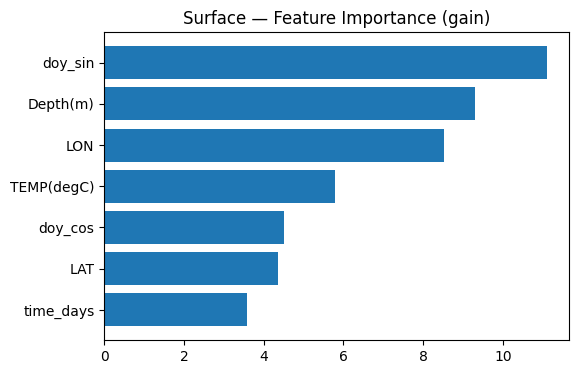

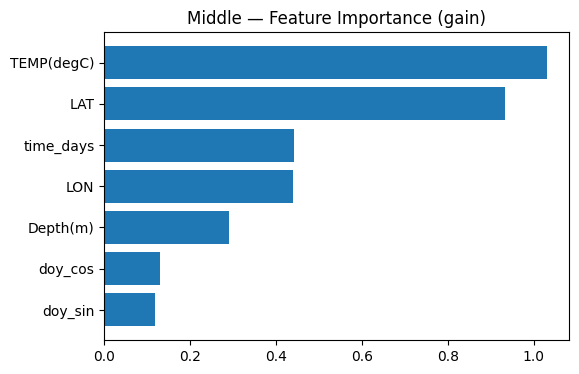

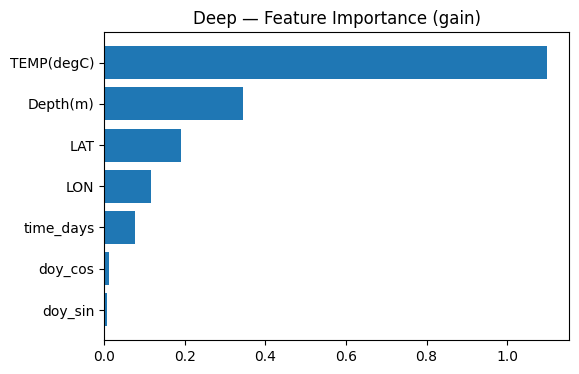


SHAP — Surface


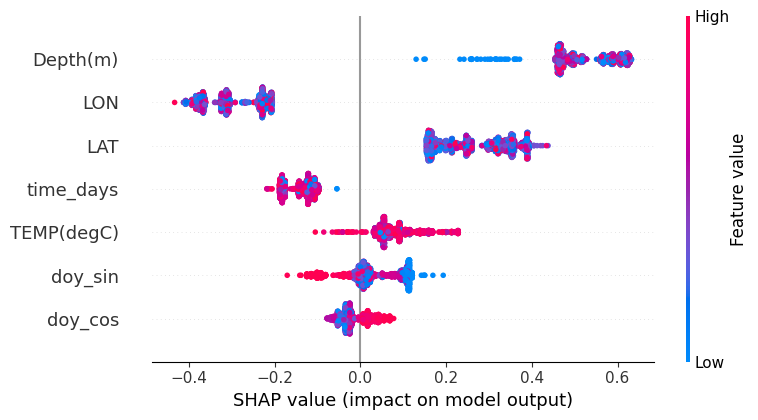

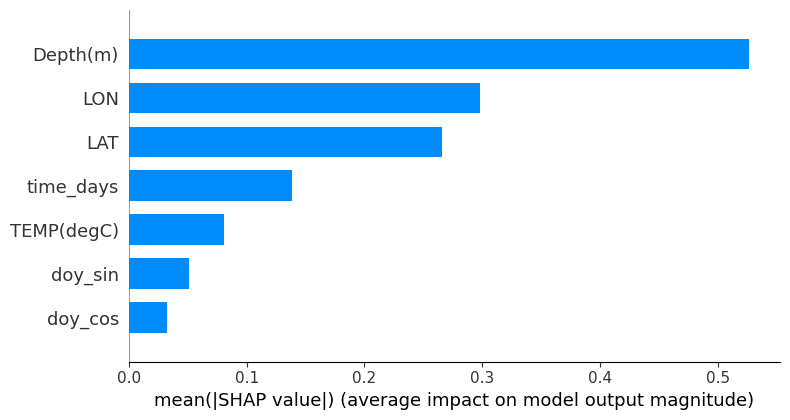


SHAP — Middle


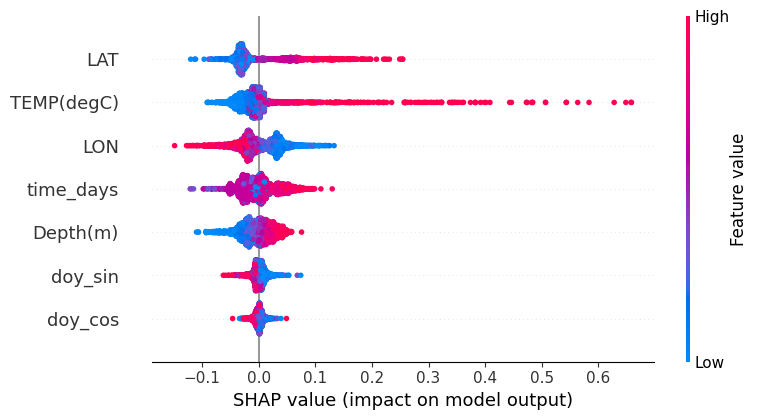

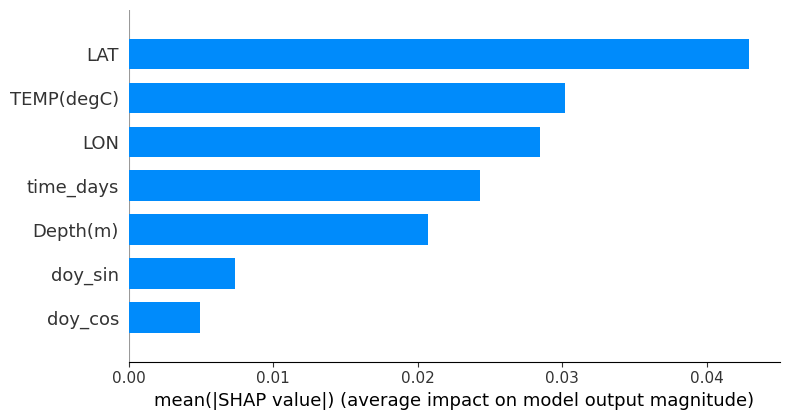


SHAP — Deep


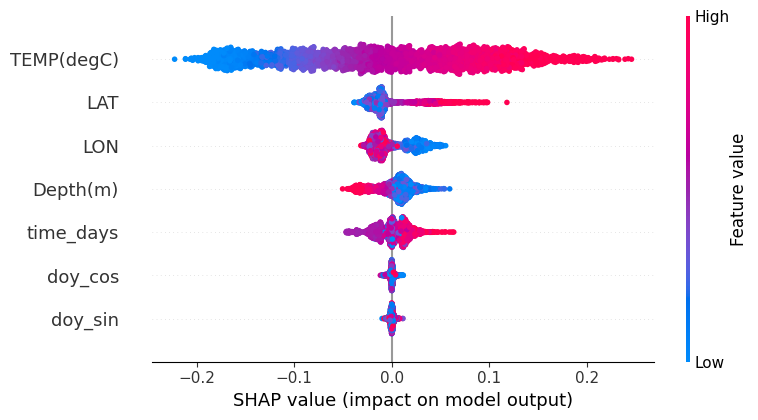

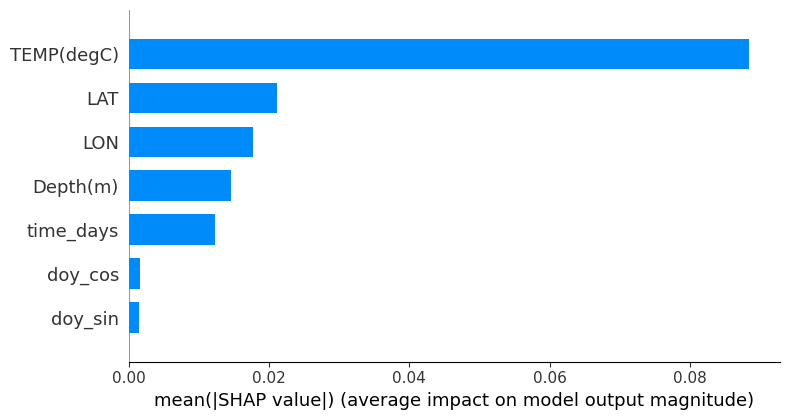

In [ ]:
#Model Information Function
def inspect_model_bundle(bundle):
    print(f"\n==============================")
    print(f"Region: {bundle['region_name']}")
    print(f"Depth range: {bundle['depth_range']}")
    print(f"==============================")

    print("\nFeatures:")
    print(bundle["features"])

    print("\nBest hyperparameters:")
    for k, v in bundle["best_hyperparams"].items():
        print(f"{k}: {v}")

    print("\nTest metrics:")
    for k, v in bundle["test_metrics"].items():
        print(f"{k}: {v:.4f}")

    print("\nPipeline structure:")
    print(bundle["model"].named_steps.keys())

    print("\nSplit information:")
    for k, v in bundle["split_info"].items():
        if isinstance(v, list):
            print(f"{k}: {len(v)} profiles")
        else:
            print(f"{k}: {v}")

    if "scaler_stats" in bundle:
      print("\nScaler statistics (metadata):")
      print("Mean:", bundle["scaler_stats"]["mean"])
      print("Scale:", bundle["scaler_stats"]["scale"])


#Feature Importance Function
def plot_feature_importance(bundle, importance_type="gain"):
    model = bundle["model"]
    features = bundle["features"]

    if hasattr(model, "named_steps"):
        xgb = model.named_steps["model"]
    else:
        xgb = model

    importance = xgb.get_booster().get_score(importance_type=importance_type)
    imp_df = (
        pd.DataFrame.from_dict(importance, orient="index", columns=["importance"])
        .rename_axis("feature")
        .reset_index()
        .sort_values("importance", ascending=False)
    )

    fmap = {f"f{i}": name for i, name in enumerate(features)}
    imp_df["feature"] = imp_df["feature"].map(fmap)

    plt.figure(figsize=(6,4))
    plt.barh(imp_df["feature"], imp_df["importance"])
    plt.gca().invert_yaxis()
    plt.title(f"{bundle['region_name']} — Feature Importance ({importance_type})")
    plt.show()


#SHAP per Region
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
def shap_per_region(df, bundle, n_samples=3000):
    features = bundle["features"]
    model = bundle["model"]
    scaler = bundle.get("scaler", None)
    dmin, dmax = bundle["depth_range"]

    df_r = df[(df["Depth(m)"] >= dmin) & (df["Depth(m)"] < dmax)]
    df_r = df_r.sample(min(n_samples, len(df_r)), random_state=42)

    X = df_r[features]

    # Extract XGBRegressor from pipeline
    pipe = bundle["model"]
    xgb = pipe.named_steps["model"]

    # SHAP Explainer
    explainer = shap.TreeExplainer(xgb)
    shap_values = explainer.shap_values(X)

    shap.summary_plot(shap_values, X, feature_names=features)
    shap.summary_plot(shap_values, X, feature_names=features, plot_type="bar")

#---------------------------------------------------------------------------------------------------------------------------------------------------------------------

for region, bundle in MODELS.items():
    inspect_model_bundle(bundle)

for bundle in MODELS.values():
    plot_feature_importance(bundle)

df = pd.read_parquet("/content/drive/MyDrive/INCOIS/Data/Raw_data.parquet")

for bundle in MODELS.values():
    print(f"\nSHAP — {bundle['region_name']}")
    shap_per_region(df, bundle)

# Sanity Check Plot

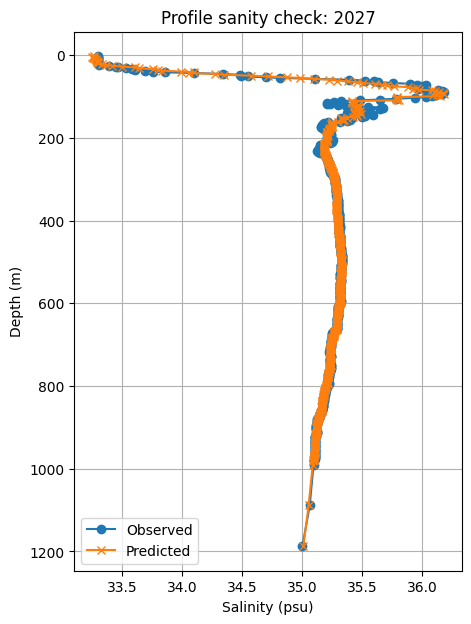

In [ ]:
def sanity_plot_random_profile(df, models):
    profile_id = np.random.choice(df["profile_id"].unique())
    df_p = df[df["profile_id"] == profile_id].copy()

    preds = []

    for region, bundle in models.items():
        dmin, dmax = bundle["depth_range"]
        mask = (df_p["Depth(m)"] >= dmin) & (df_p["Depth(m)"] < dmax)
        if not mask.any():
            continue

        X = df_p.loc[mask, bundle["features"]].values
        pipe = bundle["model"]
        y_pred = pipe.predict(X)


        preds.append(
            pd.DataFrame({
                "Depth": df_p.loc[mask, "Depth(m)"],
                "Observed": df_p.loc[mask, bundle["target"]],
                "Predicted": y_pred
                })
        )

    df_plot = pd.concat(preds).sort_values("Depth")

    plt.figure(figsize=(5,7))
    plt.plot(df_plot["Observed"], df_plot["Depth"], label="Observed", marker="o")
    plt.plot(df_plot["Predicted"], df_plot["Depth"], label="Predicted", marker="x")
    plt.gca().invert_yaxis()
    plt.xlabel("Salinity (psu)")
    plt.ylabel("Depth (m)")
    plt.title(f"Profile sanity check: {profile_id}")
    plt.legend()
    plt.grid(True)
    plt.show()

sanity_plot_random_profile(df, MODELS)

# Prediction from User Input

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import os
from google.colab import drive

# -------------------------------
# MOUNT GOOGLE DRIVE
# -------------------------------
drive.mount('/content/drive')

# -------------------------------
# MODEL REGISTRY (XGBoost)
# -------------------------------
MODEL_DIR = "/content/drive/MyDrive/INCOIS/Models"

MODEL_REGISTRY = {
    "Surface": {"path": "xgb_Surface_bundle.pkl", "depth_range": (0, 100)},
    "Middle":  {"path": "xgb_Middle_bundle.pkl", "depth_range": (100, 500)},
    "Deep":    {"path": "xgb_Deep_bundle.pkl", "depth_range": (500, 2000)}
}

# -------------------------------
# LOAD MODELS
# -------------------------------
def load_models(model_dir=MODEL_DIR, registry=MODEL_REGISTRY):
    models = {}
    for region, cfg in registry.items():
        path = os.path.join(model_dir, cfg["path"])
        bundle = joblib.load(path)
        models[region] = bundle
    return models

MODELS = load_models()


# -------------------------------
# FEATURE ENGINEERING
# -------------------------------
def add_time_features(df):
    df['DATES'] = pd.to_datetime(df['DATES'])
    ref_date = pd.Timestamp("2005-01-01")
    df['time_days'] = (df['DATES'] - ref_date).dt.total_seconds() / (24*3600)
    df['doy'] = df['DATES'].dt.dayofyear
    df['doy_sin'] = np.sin(2 * np.pi * df['doy'] / 365.25)
    df['doy_cos'] = np.cos(2 * np.pi * df['doy'] / 365.25)
    return df


# -------------------------------
# PREDICTION FUNCTION
# -------------------------------
def predict_salinity_xgb(file_path, models=MODELS, plot_profile=True, save_output=True, output_path=None):
    # 1. Load CSV
    df_new = pd.read_csv(file_path)
    df_new = add_time_features(df_new)

    # 2. Prepare output
    df_new['Predicted_PSAL'] = np.nan

    # 3. Predict region-wise
    for region, bundle in models.items():
        dmin, dmax = bundle['depth_range']
        mask = (df_new['Depth(m)'] >= dmin) & (df_new['Depth(m)'] < dmax)
        if not mask.any():
            continue

        pipe = bundle['model']  # XGBoost pipeline (with scaler if any)
        features = bundle['features']

        df_new.loc[mask, 'Predicted_PSAL'] = pipe.predict(df_new.loc[mask, features])

    # 4. Save output
    if save_output:
        if output_path is None:
            base, ext = os.path.splitext(file_path)
            output_path = f"{base}_with_predictions.csv"
        df_new.to_csv(output_path, index=False)
        print(f"Predictions saved to:\n{output_path}")

    return df_new

# -------------------------------
# USAGE
# -------------------------------
print("The input CSV must contain the following columns, in any order, with exact names: ['TEMP(degC)', 'Depth(m)', 'LAT', 'LON', 'DATES']")
file_path = input("Enter path to input CSV file: ").strip().strip('"').strip("'")
df_pred = predict_salinity_xgb(file_path)
print(df_pred.head())


MessageError: Error: credential propagation was unsuccessful